<div style="text-align: center; padding: 20px; border-radius: 10px;">
    <h1 style="color: #dd2ebd;"><b>Sign Language Recognition</b></h1>
    <h3 style="color: #3498db;"><b>Using Deep Convolutional Neural Networks</b></h3>
    <p style="color: #8ee2b5;">Phase 1: Exploratory Data Analysis</p>
    <p style="color: #dbb0ea; font-size: 18px; font-weight: bold;">By: </p>
</div>

<h1 style="color: #c5de6c; font-size: 27px"><b>Introduction</b></h1>

<p style="color: #ffffff; font-size: 16px; line-height: 1.8;">
    Since a deep understanding of the dataset is fundamental to designing effective deep learning models, 
    this phase of our project is dedicated to a comprehensive 
    <span style="color: #67e5cc; font-weight: bold;">Exploratory Data Analysis (EDA)</span> 
    and 
    <span style="color: #d6e2eb; font-weight: bold;">preprocessing</span> 
    of the provided sign language image dataset. This stage is critical, as the quality and structure of 
    the input data directly influence the performance and reliability of the convolutional neural network 
    we will develop in subsequent phases.
</p>


<h2 style="color: #6eeab4; font-size: 22px"><b>1. Dataset Overview & Class Distribution Analysis</b></h2>

<p style="color: white; font-size: 16px; line-height: 1.8;">
    Our initial investigation focuses on thoroughly examining all components of the dataset to gain 
    valuable insights into its characteristics. We begin by analyzing the class distribution to determine 
    whether the dataset contains a 
    <span style="color: #3498db; font-weight: bold;">balanced number of samples</span> 
    across all categories. This is particularly important in sign language recognition, where class 
    imbalance can lead to biased predictions and poor generalization for underrepresented letters or words.
</p>

<p style="color: white; font-size: 16px; line-height: 1.8;">
    To visualize this distribution, we generate a 
    <span style="color: #3498db; font-weight: bold;">bar chart</span> 
    that clearly illustrates the number of samples per class, enabling us to quickly identify any potential 
    imbalances that may require corrective measures such as 
    <span style="color: #3498db; font-weight: bold;">data augmentation</span> 
    or 
    <span style="color: #3498db; font-weight: bold;">class weighting</span> 
    during model training.
</p>


In [250]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


<h1 style="color: #da23a0; font-size: 27px"><b>1.1 Load Dataset & Explore Structure</b></h1>


In [248]:
from pathlib import Path

DATASET_PATH = Path("C:/Users/ASUS/Documents/alphabet")

TRAIN_PATH = DATASET_PATH / "asl_alphabet_train/asl_alphabet_train"
TEST_PATH = DATASET_PATH / "asl_alphabet_test/asl_alphabet_test"

print("DATASET OVERVIEW")

print(f"\nTrain path exists: {TRAIN_PATH.exists()}")
print(f"Test path exists:  {TEST_PATH.exists()}")

if TRAIN_PATH.exists():
    train_classes = sorted([d.name for d in TRAIN_PATH.iterdir() if d.is_dir()])
    train_counts = {cls: len(list((TRAIN_PATH / cls).glob('*.*'))) for cls in train_classes}
    
    counts = list(train_counts.values())
    class_names = list(train_counts.keys())
    
    print(f"\nTRAIN SET:")
    print(f"   Classes: {len(train_classes)}")
    print(f"   Images:  {sum(counts):,}")
    print(f"   Min:     {min(counts)} (Class: {class_names[counts.index(min(counts))]})")
    print(f"   Max:     {max(counts)} (Class: {class_names[counts.index(max(counts))]})")
    print(f"   Mean:    {sum(counts) / len(counts):.0f}")

if TEST_PATH.exists():
    test_files = list(TEST_PATH.glob('*.jpg')) + list(TEST_PATH.glob('*.jpeg')) + list(TEST_PATH.glob('*.png'))
    test_classes = sorted(set([f.stem.replace('_test', '') for f in test_files]))
    test_counts = {cls: len([f for f in test_files if f.stem.replace('_test', '') == cls]) for cls in test_classes}
    
    t_counts = list(test_counts.values())
    t_class_names = list(test_counts.keys())
    
    print(f"\nTEST SET:")
    print(f"   Images:  {len(test_files)}")
    print(f"   Classes: {len(test_classes)}")
    if t_counts:
        print(f"   Min:     {min(t_counts)} (Class: {t_class_names[t_counts.index(min(t_counts))]})")
        print(f"   Max:     {max(t_counts)} (Class: {t_class_names[t_counts.index(max(t_counts))]})")
        print(f"   Mean:    {sum(t_counts) / len(t_counts):.0f}")

if TRAIN_PATH.exists() and TEST_PATH.exists():
    missing = set(train_classes) - set(test_classes)
    print(f"\nMissing in test: {missing if missing else 'None'}")

print(f"\nTotal: {sum(train_counts.values()) + len(test_files):,} images")

DATASET OVERVIEW

Train path exists: True
Test path exists:  True

TRAIN SET:
   Classes: 29
   Images:  87,000
   Min:     3000 (Class: A)
   Max:     3000 (Class: A)
   Mean:    3000

TEST SET:
   Images:  28
   Classes: 28
   Min:     1 (Class: A)
   Max:     1 (Class: A)
   Mean:    1

Missing in test: {'del'}

Total: 87,028 images


<h1 style="color: #da23a0; font-size: 27px"><b>1.2 Class Distribution Analysis</b></h1>


In [239]:
import pandas as pd
from pathlib import Path

def count_images_train(class_dir):
    counts = {}
    if class_dir.exists():
        for class_folder in class_dir.iterdir():
            if class_folder.is_dir():
                images = list(class_folder.glob("*"))
                counts[class_folder.name] = len(images)
    return pd.Series(counts).sort_index()

def count_images_test(class_dir):
    counts = {}
    if class_dir.exists():
        subfolders = [d for d in class_dir.iterdir() if d.is_dir()]
        if subfolders:
            for class_folder in subfolders:
                images = list(class_folder.glob("*"))
                image_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
                images = [f for f in images if f.suffix.lower() in image_extensions]
                counts[class_folder.name] = len(images)
        else:
            all_files = list(class_dir.glob("*"))
            for img in all_files:
                class_name = img.stem.replace('_test', '')
                class_name = ''.join([c for c in class_name if not c.isdigit()])
                counts[class_name] = counts.get(class_name, 0) + 1
    return pd.Series(counts).sort_index()

train_counts = count_images_train(TRAIN_DIR)
test_counts = count_images_test(TEST_DIR)


print(f"\nTRAIN SET:")
print(f"   Total images: {train_counts.sum():,}")
print(f"   Number of classes: {len(train_counts)}")
if len(train_counts) > 0:
    print(f"   Min: {train_counts.min()} (Class: {train_counts.idxmin()})")
    print(f"   Max: {train_counts.max()} (Class: {train_counts.idxmax()})")
    print(f"   Mean: {train_counts.mean():.0f}")
    print(f"   Std: {train_counts.std():.1f}")

print(f"\nTEST SET:")
print(f"   Total images: {test_counts.sum():,}")
print(f"   Number of classes: {len(test_counts)}")
if len(test_counts) > 0:
    print(f"   Min: {test_counts.min()} (Class: {test_counts.idxmin()})")
    print(f"   Max: {test_counts.max()} (Class: {test_counts.idxmax()})")
    print(f"   Mean: {test_counts.mean():.0f}")

if len(train_counts) > 0 and len(test_counts) > 0:
    missing = set(train_counts.index) - set(test_counts.index)
    if missing:
        print(f"\nMissing classes in test: {', '.join(sorted(missing))}")


TRAIN SET:
   Total images: 87,000
   Number of classes: 29
   Min: 3000 (Class: A)
   Max: 3000 (Class: A)
   Mean: 3000
   Std: 0.0

TEST SET:
   Total images: 28
   Number of classes: 28
   Min: 1 (Class: A)
   Max: 1 (Class: A)
   Mean: 1

Missing classes in test: del


<h1 style="color: #e50c3b; font-size: 27px"><b>Analysis</b></h1>

As shown in the results, the training dataset contains 
<span style="color: #93c0df; font-weight: bold;">3,000 images per class</span> 
across all <span style="color: #93c0df; font-weight: bold;">29 classes</span>, 
making it <span style="color: #77e5a5; font-weight: bold;">perfectly balanced</span>. 

The test set contains <span style="color: #93c0df; font-weight: bold;">1 image per class</span> 
for <span style="color: #93c0df; font-weight: bold;">28 classes</span>, 
with the exception of the <span style="color: #e74c3c; font-weight: bold;">'del'</span> class 
which is not present in the test set. 

<span style="color: #9eedbf; font-weight: bold;">Overall, the dataset is completely balanced and well-structured for model training.</span>

<h1 style="color: #da23a0; font-size: 27px"><b>1.2.1 Class Distribution Visualization</b></h1>


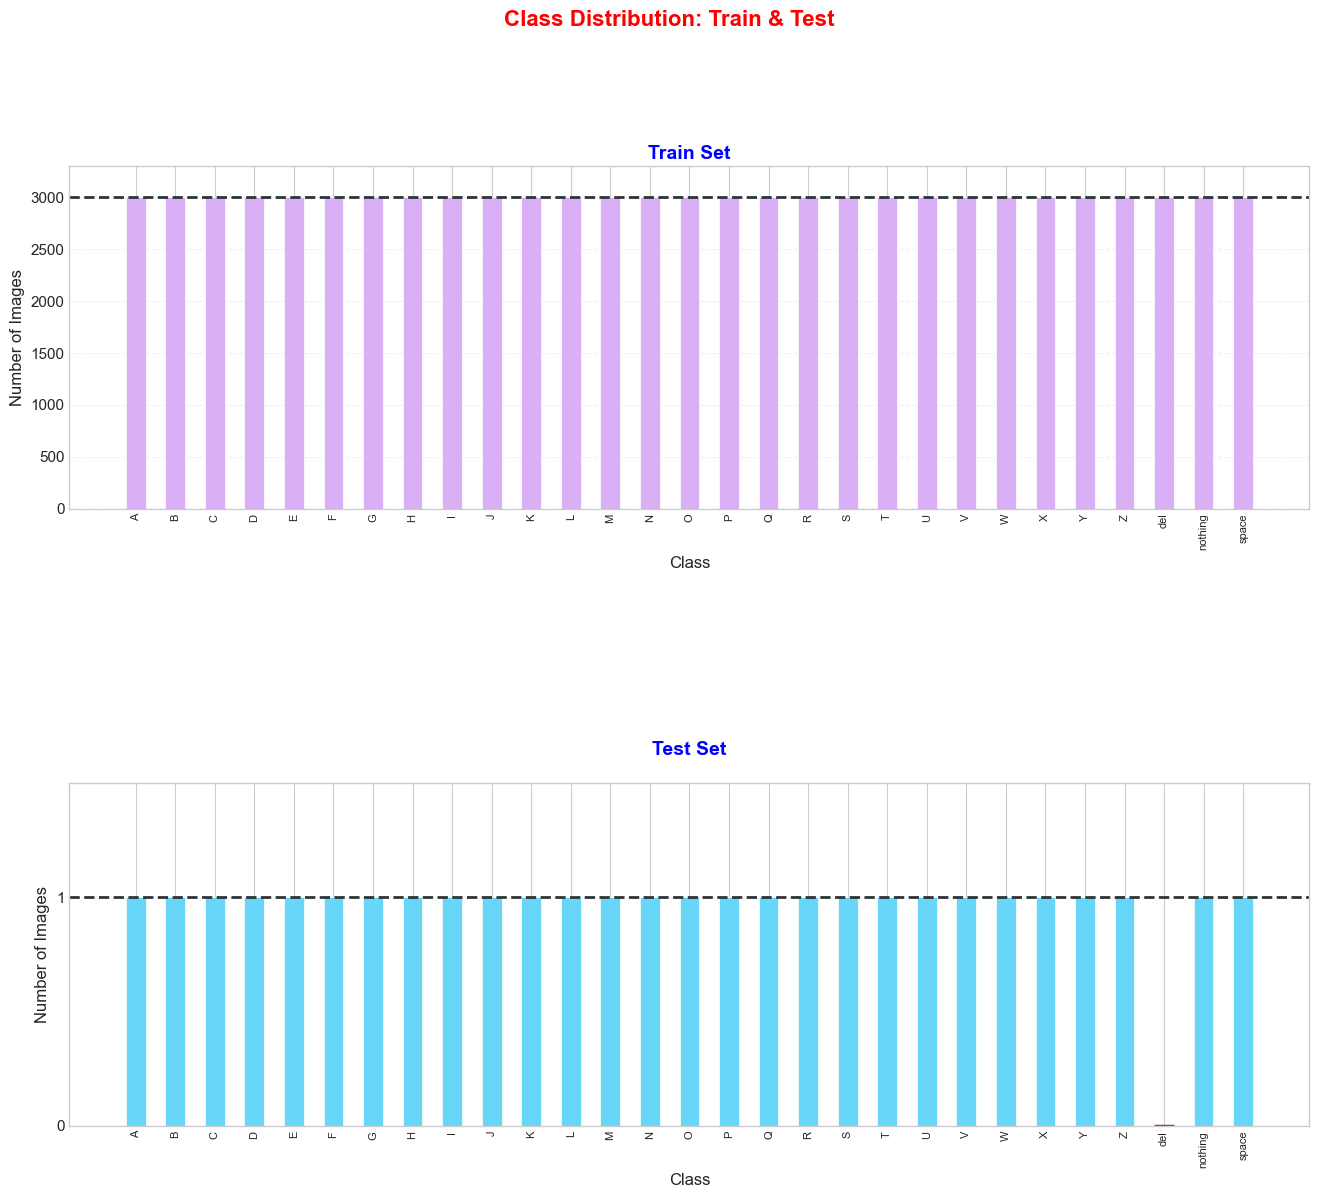

In [223]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

COLOR_TRAIN = '#d9aff6'
COLOR_TEST = '#67d6f9'  
COLOR_DEL = '#e74c3c' 
COLOR_LINE = '#2d3436'

all_classes = sorted(train_counts.index)
test_counts_aligned = test_counts.reindex(all_classes, fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.subplots_adjust(hspace=0.8, top=0.85, bottom=0.05)

axes[0].bar(train_counts.index, train_counts.values, color=COLOR_TRAIN, edgecolor='white', linewidth=0.5, width=0.5)
axes[0].axhline(y=train_counts.mean(), color=COLOR_LINE, linestyle='--', linewidth=2)
axes[0].set_title('Train Set', fontsize=14, color='blue', fontweight='bold', pad=5)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].set_ylim(0, train_counts.max() * 1.1)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

colors = [COLOR_DEL if cls == 'del' else COLOR_TEST for cls in test_counts_aligned.index]
bars = axes[1].bar(test_counts_aligned.index, test_counts_aligned.values, color=colors, edgecolor='white', linewidth=0.5, width=0.5)
axes[1].axhline(y=1, color=COLOR_LINE, linestyle='--', linewidth=2)
axes[1].set_title('Test Set', fontsize=14, color='blue', fontweight='bold', pad=20)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].set_ylim(0, 1.5)
axes[1].set_yticks([0, 1])
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

if 'del' in test_counts_aligned.index:
    del_idx = test_counts_aligned.index.get_loc('del')
    bars[del_idx].set_color(COLOR_DEL)
    bars[del_idx].set_edgecolor('#922b21')
    bars[del_idx].set_linewidth(2.5)

plt.suptitle('Class Distribution: Train & Test', fontsize=16, fontweight='bold', color='red', y=0.98)
plt.show()

<h1 style="color: #da23a0; font-size: 27px"><b>1.3 Visualize Sample Images</b></h1>


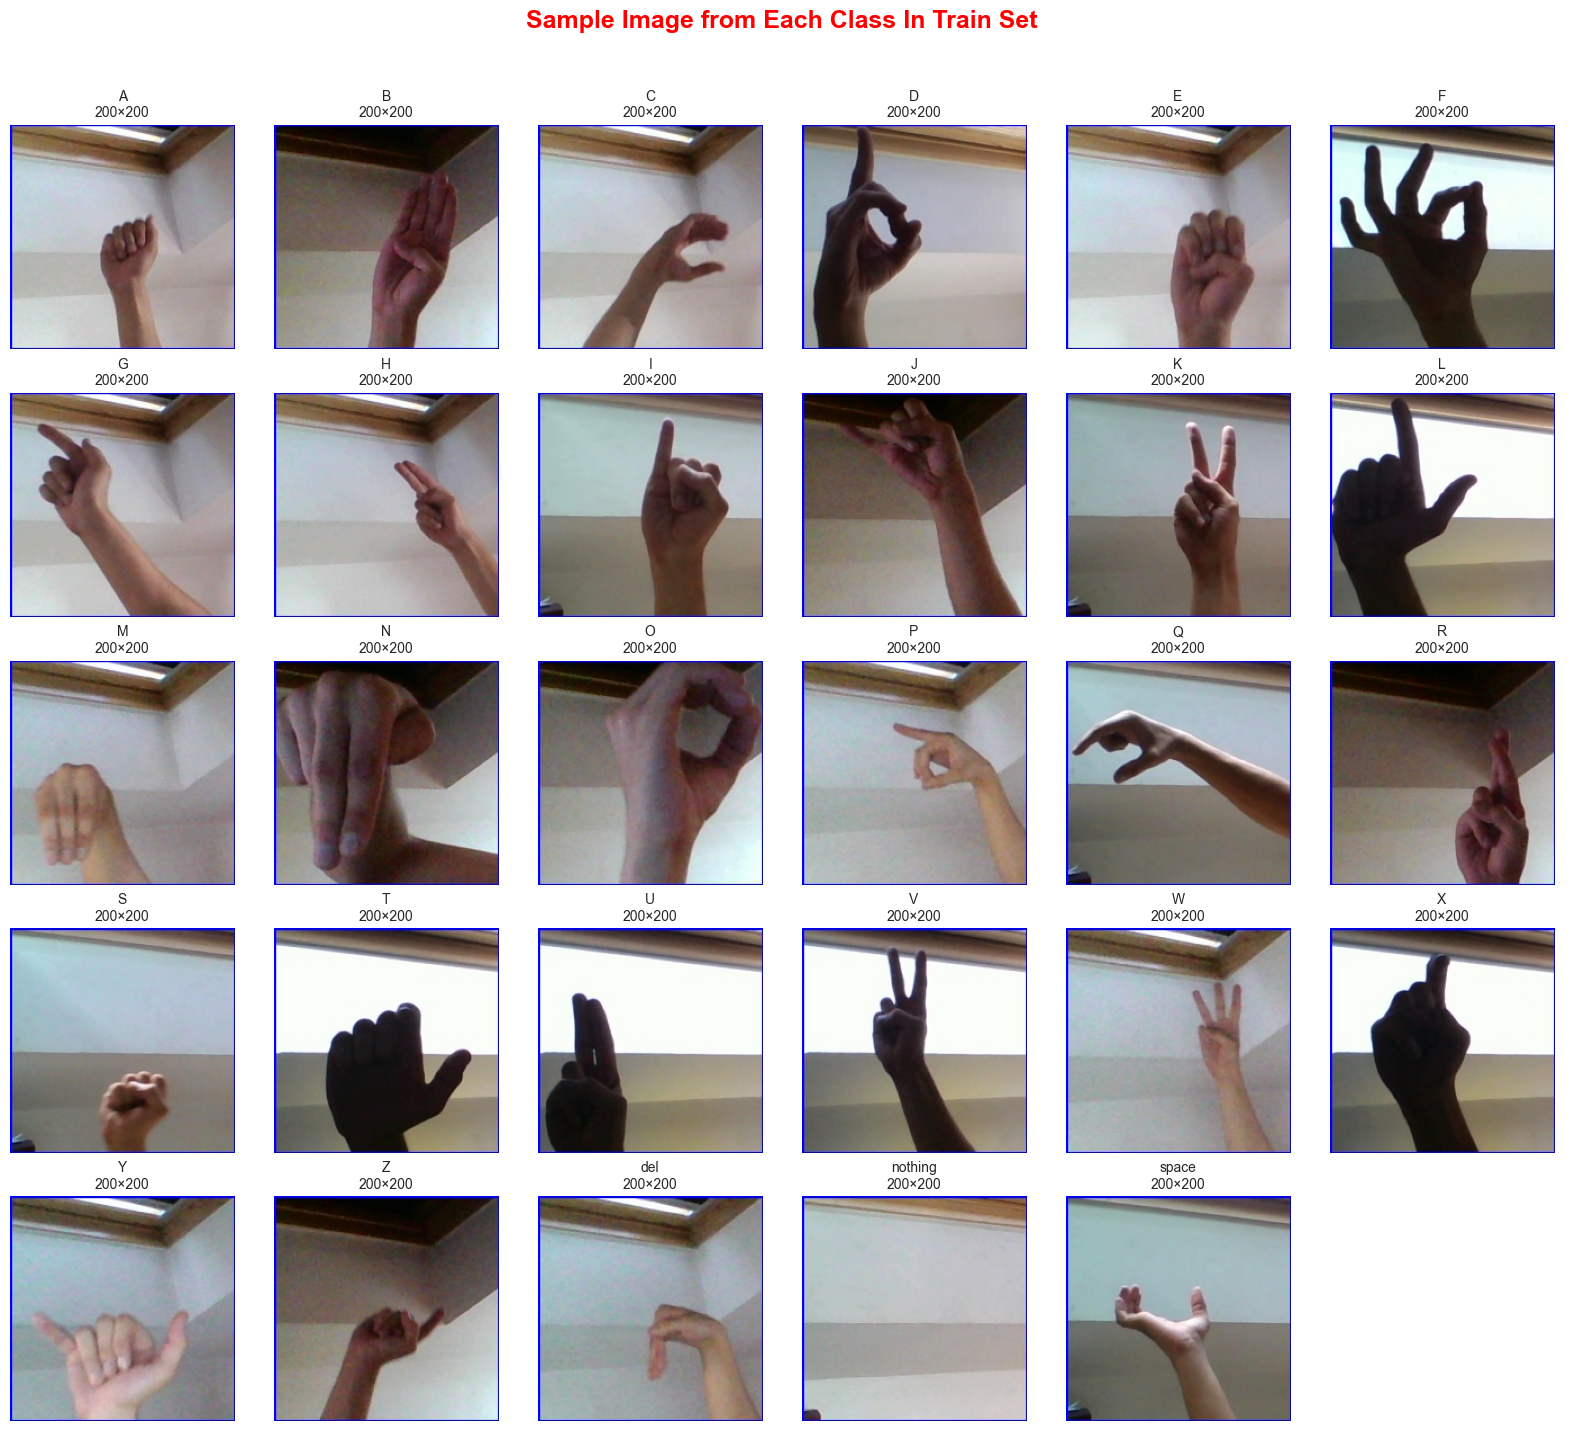

In [231]:
import random
fig, axes = plt.subplots(5, 6, figsize=(16, 14))
axes = axes.flatten()

class_names = sorted(train_counts.index.tolist())

for idx, class_name in enumerate(class_names):
    class_path = TRAIN_DIR / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.jpeg")) + list(class_path.glob("*.png"))
        if images:
            try:
                num_img = random.randint(0, len(images) - 1)
                img = Image.open(images[num_img])
                axes[idx].imshow(img)
                axes[idx].set_title(f'{class_name}\n{img.size[0]}×{img.size[1]}', fontsize=10)
            except Exception as e:
                axes[idx].set_title(f'{class_name}\n(Error loading)', fontsize=10)
        else:
            axes[idx].set_title(f'{class_name}\n(No images)', fontsize=10)
    else:
        axes[idx].set_title(f'{class_name}\n(Not found)', fontsize=10)
    axes[idx].axis('off')

for idx in range(len(class_names), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Image from Each Class In Train Set', fontsize=18, color='red', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<h1 style="color: #da23a0; font-size: 27px"><b>1.4 Image Properties Analysis</b></h1>


In [237]:
import random
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

sample_data = []
image_sizes = []
image_modes = []
aspect_ratios = []
total_images = 0

for class_name in class_names:
    class_path = TRAIN_DIR / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.jpeg")) + list(class_path.glob("*.png"))
        total_images += len(images)
        
        for img_path in images:
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    image_sizes.append((width, height))
                    image_modes.append(img.mode)
                    aspect_ratios.append(width / height if height > 0 else 0)
                    sample_data.append({
                        'class': class_name,
                        'path': str(img_path),
                        'width': width,
                        'height': height,
                        'aspect_ratio': width / height if height > 0 else 0,
                        'mode': img.mode
                    })
            except Exception as e:
                print(f"⚠️ Error opening {img_path}: {e}")

df_props = pd.DataFrame(sample_data)

print(f"\nTotal images analyzed: {len(df_props):,}")

print(f"\nColor Mode Distribution:")
print(df_props['mode'].value_counts().to_string())

print(f"\nImage Size Statistics:")
print(f"   - Width:  Min={df_props['width'].min()}, Max={df_props['width'].max()}, Mean={df_props['width'].mean():.0f}, Std={df_props['width'].std():.0f}")
print(f"   - Height: Min={df_props['height'].min()}, Max={df_props['height'].max()}, Mean={df_props['height'].mean():.0f}, Std={df_props['height'].std():.0f}")

print(f"\nAspect Ratio Statistics:")
print(f"   - Min: {df_props['aspect_ratio'].min():.2f}")
print(f"   - Max: {df_props['aspect_ratio'].max():.2f}")
print(f"   - Mean: {df_props['aspect_ratio'].mean():.2f}")
print(f"   - Median: {df_props['aspect_ratio'].median():.2f}")
print(f"   - Std: {df_props['aspect_ratio'].std():.2f}")


Total images analyzed: 87,000

Color Mode Distribution:
mode
RGB    87000

Image Size Statistics:
   - Width:  Min=200, Max=200, Mean=200, Std=0
   - Height: Min=200, Max=200, Mean=200, Std=0

Aspect Ratio Statistics:
   - Min: 1.00
   - Max: 1.00
   - Mean: 1.00
   - Median: 1.00
   - Std: 0.00


<p style="color: #d6f5f9; font-size: 16px; line-height: 1.8;">
    The results obtained from the image properties analysis reveal that the entire training dataset is 
    <span style="color: #d751c5; font-weight: bold;">perfectly uniform</span>. 
    All images share identical dimensions of 
    <span style="color: #0ec23b; font-weight: bold; padding: 2px 8px; border-radius: 5px;">200 × 200 pixels</span> 
    and are consistently formatted in the
    <span style="color: #e67e22; font-weight: bold; padding: 2px 8px; border-radius: 5px;">RGB color space</span>.
</p>

<p style="color: #d6f5f9; font-size: 16px; line-height: 1.8;">
    This standardization eliminates the need for any resizing or color conversion during preprocessing, 
    which simplifies the data pipeline and ensures seamless compatibility with the neural network input layer.
</p>

<h1 style="color: #da23a0; font-size: 27px"><b>1.4.1 Pixel Value Normalization</b></h1>

In [ ]:
import numpy as np
from PIL import Image

# Sample a few images to check pixel value distribution
sample_paths = []
for class_name in train_classes[:5]:  # Check first 5 classes
    class_path = TRAIN_DIR / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.jpeg")) + list(class_path.glob("*.png"))
        if images:
            sample_paths.append(images[0])

print(f"Analyzing {len(sample_paths)} sample images...")

pixel_values = []
for img_path in sample_paths:
    img = Image.open(img_path)
    img_array = np.array(img)
    pixel_values.extend(img_array.flatten())

pixel_values = np.array(pixel_values)

print(f"\n📊 Pixel Value Statistics (Raw - Before Normalization):")
print(f"   - Min: {pixel_values.min()}")
print(f"   - Max: {pixel_values.max()}")
print(f"   - Mean: {pixel_values.mean():.2f}")
print(f"   - Std: {pixel_values.std():.2f}")

# Show the effect of normalization
normalized_values = pixel_values / 255.0
print(f"\n📊 Pixel Value Statistics (After Normalization to [0,1]):")
print(f"   - Min: {normalized_values.min():.4f}")
print(f"   - Max: {normalized_values.max():.4f}")
print(f"   - Mean: {normalized_values.mean():.4f}")
print(f"   - Std: {normalized_values.std():.4f}")

# Visualize the distribution before and after normalization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pixel_values, bins=50, color='skyblue', edgecolor='navy', alpha=0.7)
axes[0].set_title('Raw Pixel Values (0-255)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].hist(normalized_values, bins=50, color='lightcoral', edgecolor='darkred', alpha=0.7)
axes[1].set_title('Normalized Pixel Values (0-1)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pixel Value (Scaled)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Pixel Value Distribution: Before vs After Normalization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<h1 style="color: #da23a0; font-size: 27px"><b>1.5 Summary</b></h1>
The exploratory data analysis performed on the sign language dataset reveals several key characteristics that confirm the quality and suitability of the data for deep learning applications.

**Class Distribution:**  
The training set consists of <span style="color: #2980b9; font-weight: bold;">29 distinct classes</span>, with each class containing exactly <span style="color: #27ae60; font-weight: bold;">3,000 images</span>, making the dataset <span style="color: #27ae60; font-weight: bold;">perfectly balanced</span>. This equilibrium is essential for avoiding model bias and promoting equitable learning across all categories. The test set contains <span style="color: #2980b9; font-weight: bold;">28 images</span>, with <span style="color: #2980b9; font-weight: bold;">one sample per class</span>, excluding the <span style="color: #e74c3c; font-weight: bold;">'del'</span> class — a standard omission often seen in this benchmark.

**Image Standardization:**  
All images are uniformly sized at <span style="color: #2980b9; font-weight: bold;">200×200 pixels</span> and consistently follow the <span style="color: #2980b9; font-weight: bold;">RGB color format</span>. This consistency removes the need for resizing or color space transformations during preprocessing, greatly streamlining the pipeline and ensuring smooth integration with convolutional neural networks.